<a href="https://colab.research.google.com/github/VictorManuelOrt/Biometric/blob/main/Copia_de_Ajuste_Densidades_Gabor_Ranking_Biometrics_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install opencv-python numpy


In [ ]:
!pip install onnx onnxruntime pydantic==1.10.16 huggingface-hub pyyaml
!pip install --no-deps open-iris

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 71.7 MB/s eta 0:00:00
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.3
    Uninstalling pydantic-2.12.3:
      Successfully uninstalled pydantic-2.12.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.26.0 requires pydantic<3.0.0,>=2.7.0, but you have pydantic 1.10.16 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 1.10.16 which is incompatible.
langsmith 0.7.13 requires pydantic<3,>=2, but you have pydantic 1.10.16 which is incompatible.
mcp 1.26.0 requires pydantic<3.0.0,>=2.11.0,

In [4]:
!pip install fitter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstal

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olankadhim/multimodal-biometric-dataset-mulb")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multimodal-biometric-dataset-mulb' dataset.
Path to dataset files: /kaggle/input/multimodal-biometric-dataset-mulb


In [ ]:
import kagglehub

In [ ]:
os.listdir(kagglehub.dataset_download("olankadhim/multimodal-biometric-dataset-mulb"))

 16%|█▌        | 2.01G/12.7G [00:34<03:03, 62.6MB/s]


KeyboardInterrupt: 

In [ ]:
import iris

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import os
from PIL import Image
import matplotlib.pyplot as plt
import os
import math
import pandas as pd
from fitter import Fitter

In [2]:
from google.colab.patches import cv2_imshow

In [ ]:
path

'/kaggle/input/multimodal-biometric-dataset-mulb'

In [3]:
def gabor_kernel(theta, phi, sigma):
    """
    Construye un kernel de Gabor complejo:

    g(x,y) = exp(-(x^2 + y^2)/sigma^2) *
             exp(2*pi*i*theta*(x*cos(phi) + y*sin(phi)))

    El tamaño del kernel se fija como +/- 3*sigma.
    """

    # Tamaño del kernel (impar)
    half = int(np.ceil(3 * sigma))
    K = 2 * half + 1

    # Sistema de coordenadas centrado en (0,0)
    x = np.arange(-half, half + 1)
    y = np.arange(-half, half + 1)
    X, Y = np.meshgrid(x, y)

    # Proyección direccional
    s = X * np.cos(phi) + Y * np.sin(phi)

    # Gaussiana (ventana suave)
    gaussian = np.exp(-(X**2 + Y**2) / sigma**2)

    # Onda compleja (frecuencia + orientación)
    wave = np.exp(2j * np.pi * theta * s)

    # Kernel de Gabor complejo
    kernel = gaussian * wave

    return kernel

def apply_gabor(image, kernel):
    """
    Aplica un filtro de Gabor complejo a una imagen.
    Retorna la magnitud de la respuesta.
    """

    # Asegurar tipo float
    image = image.astype(np.float64)

    # Separar partes real e imaginaria del kernel
    real_k = np.real(kernel)
    imag_k = np.imag(kernel)

    # Convolución (modo 'same' mantiene tamaño)
    real_resp = cv.filter2D(image, cv.CV_64F, real_k)
    imag_resp = cv.filter2D(image, cv.CV_64F, imag_k)

    # Magnitud (energía local)
    magnitude = np.sqrt(real_resp**2 + imag_resp**2)

    return magnitude


distancia_euclidiana Regular-Bien

similitud_coseno Mala

distancia_manhattan Regular-Bien mejor que euclideana

dot_product Muy mala

distancia_chebyshev Regular

distancia_minkowski p=3 Regular como euclidiana

correlacion_pearson Mala

cosine_similarity_normalizada Mala

distancia_angular Mala Regular

distancia_euclidiana_normalizada Regular aceptable (se ajusta mejor la chi2)



In [4]:
def distancia_euclidiana(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])
    return np.linalg.norm(v1 - v2)

def similitud_coseno(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    dot = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)

    return dot / (norm1 * norm2)

def distancia_manhattan(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    return np.sum(np.abs(v1 - v2))

def dot_product(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    return np.dot(v1, v2)

def distancia_chebyshev(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    return np.max(np.abs(v1 - v2))

def distancia_minkowski(dic1, dic2, clave1, clave2, p=3):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])
    p=3
    return np.sum(np.abs(v1 - v2)**p)**(1/p)

def correlacion_pearson(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    return np.corrcoef(v1, v2)[0,1]

def cosine_similarity_normalizada(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)

    return np.dot(v1, v2)

def distancia_angular(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

    return np.arccos(np.clip(cos_sim, -1.0, 1.0))

def distancia_euclidiana_normalizada(dic1, dic2, clave1, clave2):
    v1 = np.array(dic1[clave1])
    v2 = np.array(dic2[clave2])

    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)

    return np.linalg.norm(v1 - v2)


In [5]:
# -----------------------------
# Parámetros fijos
# -----------------------------
sigma = 80.0
kernel_size = int(2 * np.ceil(3 * sigma) + 1)

# 4 frecuencias espaciales
thetas = [0.02, 0.04, 0.08]

# 4 orientaciones: k*pi/4
phis = [k * np.pi / 4 for k in range(4)]


In [ ]:
#lo siguiente seria juntar todo en uns funcion y  solo ajustar
#en una celda parametrso del filstro de gabor
#nombre de imagen a sacar caracteristicas
#guardar valores en vectores para hacer comparaciones


#umbral de pertenencia en terminos con juegos?

In [6]:
#Dar acceso a Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#copiar carpeta de Drive a mi carpeta de content
!cp -r /content/drive/MyDrive/IrisIMG /content/

In [ ]:
#Verificar Cantidad de datos
len(os.listdir("/content/IrisIMG"))

3452

In [ ]:
name_image=os.listdir("/content/IrisIMG")[0]
name_image

'FH_4.jpg'

In [ ]:
os.path.join("/content/IrisIMG", name_image)

'/content/IrisIMG/FH_4.jpg'

In [7]:
Features_Dictionary = {}
def Add_Features_Dictionary(name_image):


    name_img=name_image
    #Genera un vector
    Features_Vector = []

    # Leer imagen en escala de grises
    img = cv.imread(os.path.join("/content/IrisIMG", name_img), cv.IMREAD_GRAYSCALE)
    img = img.astype(np.float64) / 255.0

    # Visualización
    fig, axes = plt.subplots(
        len(thetas),
        len(phis),
        figsize=(12, 8),
        sharex=True,
        sharey=True
    )
    for i, theta in enumerate(thetas):
        for j, phi in enumerate(phis):
            # Construir kernel
            kernel = gabor_kernel(theta, phi, sigma)
            # Aplicar filtro
            response = apply_gabor(img, kernel)
            # Normalizar respuesta
            response_norm = response / (response.max() + 1e-8)
            ax = axes[i, j]
            ax.imshow(response_norm, cmap='gray')
            ax.axis('off')
            # Títulos solo en bordes (más limpio)
            ax.set_title(rf"$\theta = {theta},\ \varphi = {j}\pi/4,\mu_c = {round(response.mean(),3)},\sigma_c = {round(response.std(),3)} $", fontsize=9)
            Features_Vector.append(response.mean())
            Features_Vector.append(response.std())
    plt.suptitle(
        rf"Banco de filtros de Gabor (3 frecuencias × 4 orientaciones){name_img}",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(name_img.replace("_", "R"))
    plt.close()

    # Guardamos las caracteristicas en el diccionario
    Features_Dictionary[name_img] = Features_Vector



In [8]:
Features_Dictionary = {}
def Add_Features_Dictionary(name_image):

    name_img=name_image
    #Genera un vector
    Features_Vector = []

    # Leer imagen en escala de grises
    img = cv.imread(os.path.join("/content/IrisIMG", name_img), cv.IMREAD_GRAYSCALE)
    img = img.astype(np.float64) / 255.0

    for i, theta in enumerate(thetas):
        for j, phi in enumerate(phis):
            # Construir kernel
            kernel = gabor_kernel(theta, phi, sigma)
            # Aplicar filtro
            response = apply_gabor(img, kernel)
            # Normalizar respuesta
            response_norm = response / (response.max() + 1e-8)
            # Títulos solo en bordes (más limpio)
            Features_Vector.append(response.mean())
            Features_Vector.append(response.std())

    # Guardamos las caracteristicas en el diccionario
    Features_Dictionary[name_img] = Features_Vector


In [ ]:
for archivo in sorted(os.listdir("/content/IrisIMG"))[2500:3000]:
    if archivo.endswith(".jpg"):
      try:
        Add_Features_Dictionary(archivo)
      except Exception:
        continue

In [ ]:
len(Features_Dictionary)

3000

In [ ]:
#Guardar el diccionario con caracteristicas generadas_NO ejecutar
import pickle

ruta = "/content/drive/MyDrive/GaborFeatures_Dictionary25003000.pkl"

with open(ruta, "wb") as f:
    pickle.dump(Features_Dictionary, f)

In [9]:
#Importamos diccionario guardado_No ejecutar
import pickle

ruta = "/content/drive/MyDrive/GaborFeatures_Dictionary003000.pkl"

with open(ruta, "rb") as f:
    results_dict = pickle.load(f)

In [10]:
len(results_dict)

3000

In [46]:
first_1000_items = list(results_dict.items())[:200]
Features_Dictionary = dict(first_1000_items)

print(f"Original dictionary size: {len(results_dict)}")
print(f"New dictionary size: {len(Features_Dictionary)}")

Original dictionary size: 3000
New dictionary size: 200


In [47]:
df = pd.DataFrame(index=Features_Dictionary.keys(), columns=Features_Dictionary.keys())

In [13]:
df

,AA_1.jpg,AA_10.jpg,AA_11.jpg,AA_12.jpg,AA_13.jpg,AA_14.jpg,AA_15.jpg,AA_16.jpg,AA_17.jpg,AA_18.jpg,...,AC_1.jpg,AC_10.jpg,AC_11.jpg,AC_12.jpg,AC_13.jpg,AC_14.jpg,AC_15.jpg,AC_16.jpg,AC_17.jpg,AC_18.jpg
AA_1.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_10.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_11.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_12.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_13.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_14.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_15.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_16.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_17.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AA_18.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
for i in Features_Dictionary.keys():
    for j in Features_Dictionary.keys():
        df.loc[i, j] = distancia_euclidiana_normalizada(Features_Dictionary, Features_Dictionary, i, j)


In [15]:
df

,AA_1.jpg,AA_10.jpg,AA_11.jpg,AA_12.jpg,AA_13.jpg,AA_14.jpg,AA_15.jpg,AA_16.jpg,AA_17.jpg,AA_18.jpg,...,AC_1.jpg,AC_10.jpg,AC_11.jpg,AC_12.jpg,AC_13.jpg,AC_14.jpg,AC_15.jpg,AC_16.jpg,AC_17.jpg,AC_18.jpg
AA_1.jpg,0.0,0.056174,0.072553,0.074389,0.079195,0.088802,0.072438,0.104631,0.088813,0.089379,...,0.167957,0.163058,0.163058,0.163058,0.142148,0.142148,0.142148,0.142148,0.148783,0.148783
AA_10.jpg,0.056174,0.0,0.035449,0.055532,0.043336,0.074403,0.060497,0.067953,0.077508,0.062033,...,0.156824,0.14394,0.14394,0.14394,0.136096,0.136096,0.136096,0.136096,0.138269,0.138269
AA_11.jpg,0.072553,0.035449,0.0,0.036224,0.038048,0.057319,0.048912,0.04347,0.063258,0.04547,...,0.136352,0.121565,0.121565,0.121565,0.116829,0.116829,0.116829,0.116829,0.114772,0.114772
AA_12.jpg,0.074389,0.055532,0.036224,0.0,0.044011,0.038589,0.044539,0.060314,0.045796,0.043965,...,0.133022,0.11815,0.11815,0.11815,0.104899,0.104899,0.104899,0.104899,0.106775,0.106775
AA_13.jpg,0.079195,0.043336,0.038048,0.044011,0.0,0.057824,0.048856,0.062488,0.066684,0.042155,...,0.14011,0.121407,0.121407,0.121407,0.123178,0.123178,0.123178,0.123178,0.124473,0.124473
AA_14.jpg,0.088802,0.074403,0.057319,0.038589,0.057824,0.0,0.0386,0.071351,0.029745,0.042964,...,0.108907,0.092817,0.092817,0.092817,0.080661,0.080661,0.080661,0.080661,0.088505,0.088505
AA_15.jpg,0.072438,0.060497,0.048912,0.044539,0.048856,0.0386,0.0,0.066057,0.044876,0.03404,...,0.110738,0.099512,0.099512,0.099512,0.091401,0.091401,0.091401,0.091401,0.097552,0.097552
AA_16.jpg,0.104631,0.067953,0.04347,0.060314,0.062488,0.071351,0.066057,0.0,0.072204,0.052685,...,0.122161,0.109082,0.109082,0.109082,0.108381,0.108381,0.108381,0.108381,0.09616,0.09616
AA_17.jpg,0.088813,0.077508,0.063258,0.045796,0.066684,0.029745,0.044876,0.072204,0.0,0.04484,...,0.109776,0.103531,0.103531,0.103531,0.075187,0.075187,0.075187,0.075187,0.088238,0.088238
AA_18.jpg,0.089379,0.062033,0.04547,0.043965,0.042155,0.042964,0.03404,0.052685,0.04484,0.0,...,0.113753,0.098954,0.098954,0.098954,0.097233,0.097233,0.097233,0.097233,0.097135,0.097135


In [49]:
len(df.to_numpy().flatten())

40000

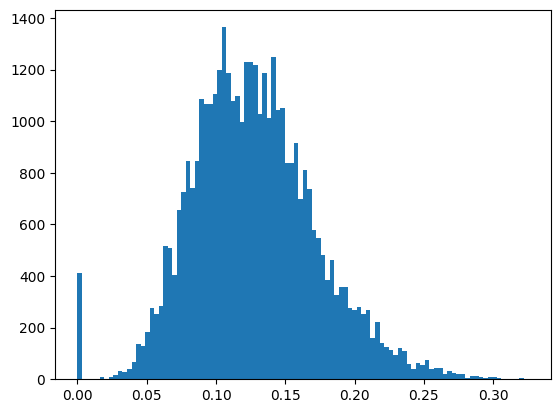

In [50]:
import matplotlib.pyplot as plt

plt.hist(df.to_numpy().flatten(), bins=100)

plt.show()

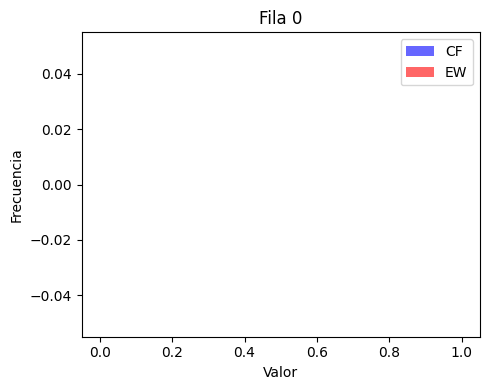

In [ ]:
import matplotlib.pyplot as plt

filas = [0]          # filas que quieres graficar
claves = ["CF", "EW"]      # prefijos
colors = ["blue", "red"]

fig, axes = plt.subplots(1, len(filas), figsize=(5*len(filas),4))

if len(filas) == 1:
    axes = [axes]

for ax, fila in zip(axes, filas):

    for clave, color in zip(claves, colors):

        cols = [c for c in df.columns if c.startswith(clave)]
        data = df.iloc[fila][cols]

        ax.hist(data, bins=10, alpha=0.6, color=color, label=clave)

    ax.set_title(f"Fila {fila}")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
plt.show()

In [51]:
same_prefix_values = []
diff_prefix_values = []

# recorrer filas y columnas
for fila in df.index:
    for col in df.columns:

        # descartar claves idénticas
        #se puede omitir si se quiere la barra de la izquierda
        if fila == col:
            continue

        #este es para descartar casos de posibe duplicado de imagenes
        if 0 == df.loc[fila, col]:
            continue

        pref_fila = str(fila)[:2]
        pref_col = str(col)[:2]

        value = df.loc[fila, col]

        if pref_fila == pref_col:
            same_prefix_values.append(value)
        else:
            diff_prefix_values.append(value)

same_prefix_values = np.array(same_prefix_values)
diff_prefix_values = np.array(diff_prefix_values)

same = np.array(same_prefix_values)
diff = np.array(diff_prefix_values)

In [ ]:
!pip uninstall -y numpy
!pip uninstall -y numpy
!pip uninstall -y numpy

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


In [ ]:
!pip install numpy==1.26.4 scipy==1.11.4 fitter joblib --no-cache-dir

In [ ]:
!pip install --upgrade --force-reinstall numpy scipy

  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.8 MB/s eta 0:00:00
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 9.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fitter 1.7.1 requires numpy<2.0.0,>=1.20.0, but you have numpy 2.4.3 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 whic

In [ ]:
import os
os.kill(os.getpid(), 9)

In [18]:
len(same)

754

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
johnsonsb,63.851101,138.488732,169.389523,inf,0.014776,0.001328
lognorm,63.883358,126.564697,149.740290,inf,0.016685,0.000178
norminvgauss,63.897365,144.210678,175.111469,inf,0.014302,0.002107
johnsonsu,63.910472,128.426696,159.327487,inf,0.017298,0.000088
invgauss,63.922178,142.396201,165.571794,inf,0.013764,0.003494


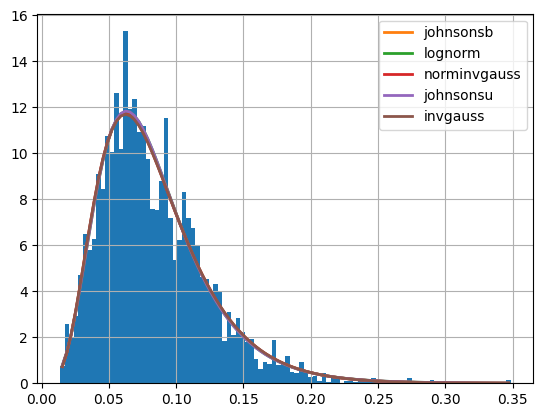

In [ ]:

data = same

f = Fitter(data)   # no especificas distribuciones
f.fit()

f.summary()

              sumsquare_error           aic           bic    kl_div  \
norminvgauss       779.407562 -14362.269562 -14337.786018  0.212992   
johnsonsu          783.600156 -14358.525341 -14334.041797  0.211369   
lognorm            797.104783 -14356.174661 -14337.812003  0.201694   
johnsonsb          798.401244 -14353.483957 -14329.000413  0.198713   
invgauss           802.816446 -14354.006900 -14335.644242  0.197228   

              ks_statistic  ks_pvalue  
norminvgauss      0.032754   0.001433  
johnsonsu         0.032490   0.001610  
lognorm           0.034452   0.000664  
johnsonsb         0.035031   0.000506  
invgauss          0.035488   0.000407  


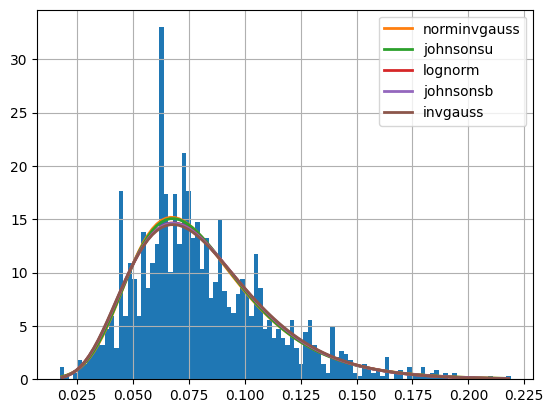

In [52]:


f = Fitter(same, distributions=['johnsonsb', 'norminvgauss', 'johnsonsu', 'invgauss',
        'norm','expon','gamma','beta','chi2','lognorm',
        't','cauchy','laplace',
        'weibull_min','erlang',
        'uniform','triang',
        'chi','ncx2'
    ])
f.fit()
print(f.summary())

KL divergence emp|Teo: 0.015392432439802681
KL divergence Teo|emp: 0.014855408650259229
KS statistic: 0.035030825328699944
p-value: 0.0005063683663013922


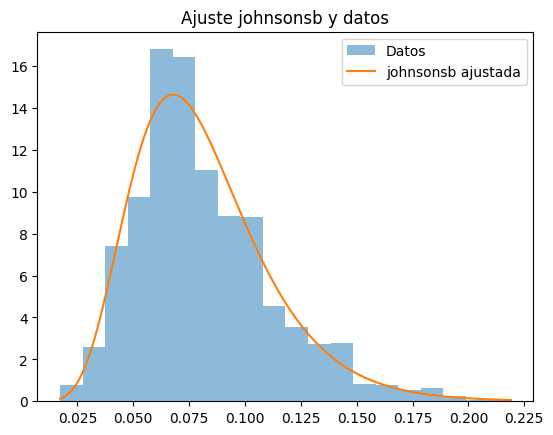

In [53]:

from scipy import stats

# =========================
# 1. Datos
# =========================
data = np.array(same)


# =========================
# 2. Histograma (P empírica)
# =========================
bins = 20

hist, bin_edges = np.histogram(data, bins=bins, density=True)

# centros de los bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# =========================
# 3. Ajuste johnsonsb (Q)
# =========================
params = stats.johnsonsb.fit(data)

q_pdf = stats.johnsonsb.pdf(bin_centers, *params)

# =========================
# 4. Evitar ceros (CLAVE)
# =========================
epsilon = 1e-10

p = np.maximum(hist, epsilon)
q = np.maximum(q_pdf, epsilon)

# =========================
# 5. Normalización (opcional pero recomendable)
# =========================
p = p / np.sum(p)
q = q / np.sum(q)

# =========================
# 6. KL divergence
# =========================
kl = np.sum(p * np.log(p / q))

print("KL divergence emp|Teo:", kl)

kl1 = np.sum(q * np.log(q / p))

print("KL divergence Teo|emp:", kl1)

ks_stat, p_value = stats.kstest(same, 'johnsonsb', args=params)

print("KS statistic:", ks_stat)
print("p-value:", p_value)

# =========================
# 7. Visualización
# =========================
x = np.linspace(min(data), max(data), 500)
pdf_fit = stats.johnsonsb.pdf(x, *params)

plt.hist(data, bins=bins, density=True, alpha=0.5, label="Datos")
plt.plot(x, pdf_fit, label="johnsonsb ajustada")

plt.legend()
plt.title("Ajuste johnsonsb y datos")
plt.show()

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
lognorm,1.256536,107.878378,143.267453,inf,0.005136,6.659254e-23
gumbel_r,2.977348,77.407342,101.000059,inf,0.010310,5.336632e-91
kstwobign,4.359216,147.032195,170.624911,inf,0.013707,1.581532e-160
gamma,10.473598,162.800750,198.189825,inf,0.021508,0.000000e+00
logistic,62.319039,157.528819,181.121536,inf,0.042202,0.000000e+00


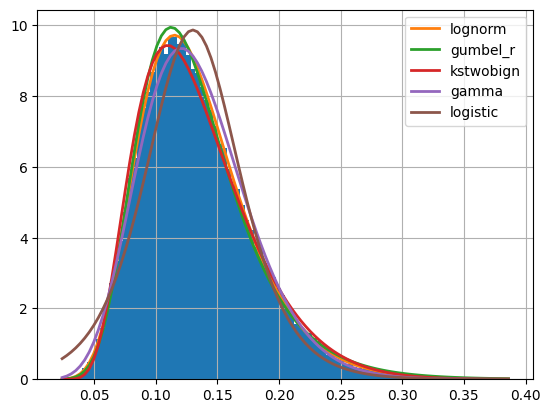

In [ ]:
from fitter import Fitter

data = diff

f = Fitter(data)   # no especificas distribuciones
f.fit()

f.summary()

In [ ]:
len(diff)

981030

           sumsquare_error            aic            bic    kl_div  \
beta             31.670134 -130137.928810 -130103.938681  0.011467   
johnsonsb        31.901494 -130138.945534 -130104.955405  0.011818   
gamma            32.065092 -130127.704969 -130102.212372  0.012674   
chi2             32.065098 -130127.704969 -130102.212372  0.012674   
erlang           32.065111 -130127.704969 -130102.212372  0.012674   

           ks_statistic  ks_pvalue  
beta           0.009284   0.003855  
johnsonsb      0.009761   0.001997  
gamma          0.010564   0.000611  
chi2           0.010564   0.000612  
erlang         0.010564   0.000612  


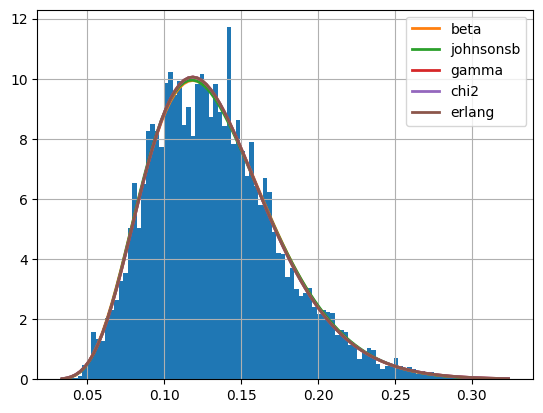

In [54]:
from fitter import Fitter
import numpy as np


f = Fitter(diff, distributions=['johnsonsb', 'norminvgauss', 'johnsonsu', 'invgauss',
                                'gumbel_r', 'kstwobign', 'logistic',
        'norm','expon','gamma','beta','chi2','lognorm',
        't','cauchy','laplace',
        'weibull_min','erlang',
        'uniform','triang',
        'chi','ncx2'
    ])
f.fit()
print(f.summary())

KL divergence emp|Teo: 0.009362902834686455
KL divergence Teo|emp: 0.016106663975839815
KS statistic: 0.5501564844499045
p-value: 0.0


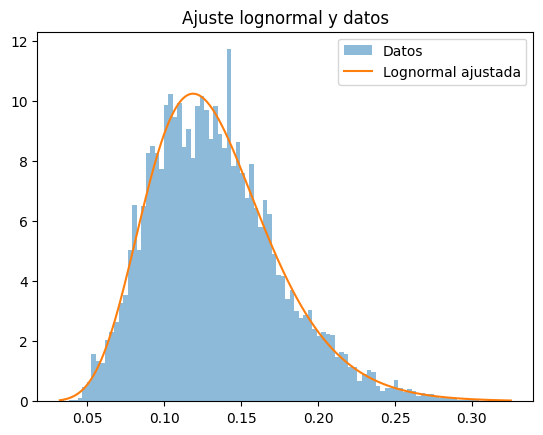

In [55]:

from scipy import stats

# =========================
# 1. Datos
# =========================
data = np.array(diff)


# =========================
# 2. Histograma (P empírica)
# =========================
bins = 100

hist, bin_edges = np.histogram(data, bins=bins, density=True)

# centros de los bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# =========================
# 3. Ajuste lognormal (Q)
# =========================
params = stats.lognorm.fit(data)

q_pdf = stats.lognorm.pdf(bin_centers, *params)

# =========================
# 4. Evitar ceros (CLAVE)
# =========================
epsilon = 1e-10

p = np.maximum(hist, epsilon)
q = np.maximum(q_pdf, epsilon)

# =========================
# 5. Normalización (opcional pero recomendable)
# =========================
p = p / np.sum(p)
q = q / np.sum(q)

# =========================
# 6. KL divergence
# =========================
kl = np.sum(p * np.log(p / q))

print("KL divergence emp|Teo:", kl)

kl1 = np.sum(q * np.log(q / p))

print("KL divergence Teo|emp:", kl1)

ks_stat, p_value = stats.kstest(same, 'lognorm', args=params)

print("KS statistic:", ks_stat)
print("p-value:", p_value)
# =========================
# 7. Visualización
# =========================
x = np.linspace(min(data), max(data), 500)
pdf_fit = stats.lognorm.pdf(x, *params)

plt.hist(data, bins=bins, density=True, alpha=0.5, label="Datos")
plt.plot(x, pdf_fit, label="Lognormal ajustada")

plt.legend()
plt.title("Ajuste lognormal y datos")
plt.show()

In [58]:
import numpy as np

C10 = 1   # costo FAR
C01 = 1    # costo FRR

thresholds = np.linspace(
    min(np.min(same), np.min(diff)),
    max(np.max(same), np.max(diff)),
    1000
)

far = []
frr = []

for t in thresholds:
    far.append(np.mean(diff >= t))
    frr.append(np.mean(same < t))

far = np.array(far)
frr = np.array(frr)

# minimizar el máximo ponderado
risk = np.maximum(C10 * far, C01 * frr)

idx = np.argmin(risk)

tau_star = thresholds[idx]

print("tau*:", tau_star)
print("FAR:", far[idx])
print("FRR:", frr[idx])

tau*: 0.10079672619358278
FAR: 0.7674046265113454
FRR: 0.7669441141498217


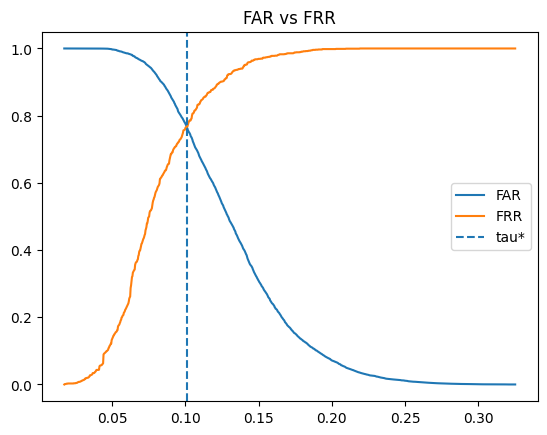

In [59]:
import matplotlib.pyplot as plt

plt.plot(thresholds, far, label="FAR")
plt.plot(thresholds, frr, label="FRR")

plt.axvline(tau_star, linestyle='--', label="tau*")

plt.legend()
plt.title("FAR vs FRR")
plt.show()

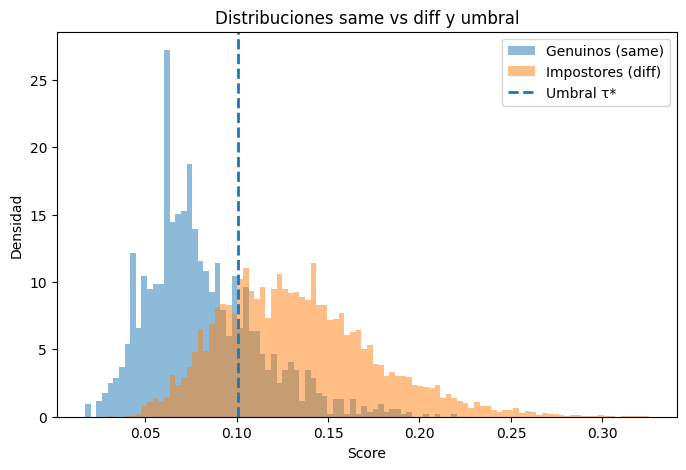

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Asegurar arrays
same_arr = np.array(same)
diff_arr = np.array(diff)

# =========================
# 1. Rango común
# =========================
xmin = min(same_arr.min(), diff_arr.min())
xmax = max(same_arr.max(), diff_arr.max())

# =========================
# 2. Graficar histogramas
# =========================
bins = 100

plt.figure(figsize=(8,5))

plt.hist(same_arr, bins=bins, range=(xmin, xmax),
         density=True, alpha=0.5, label="Genuinos (same)")

plt.hist(diff_arr, bins=bins, range=(xmin, xmax),
         density=True, alpha=0.5, label="Impostores (diff)")

# =========================
# 3. Dibujar umbral
# =========================
plt.axvline(tau_star, linestyle='--', linewidth=2, label="Umbral τ*")

# =========================
# 4. Detalles
# =========================
plt.xlabel("Score")
plt.ylabel("Densidad")
plt.title("Distribuciones same vs diff y umbral")
plt.legend()

plt.show()

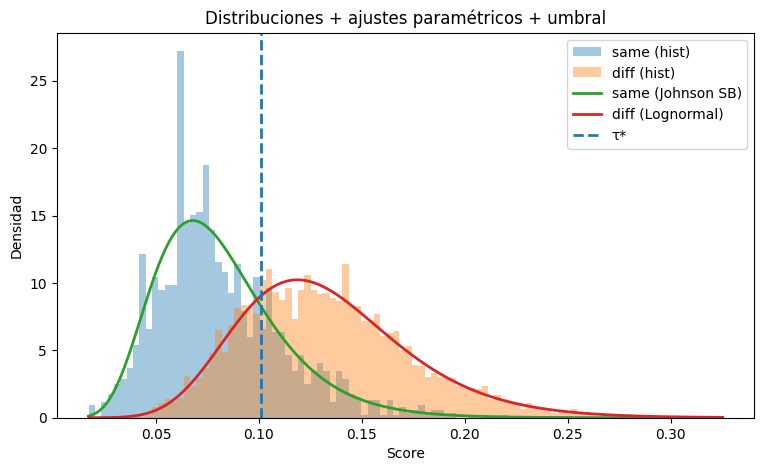

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Datos
# =========================
same_arr = np.array(same)
diff_arr = np.array(diff)

# limpieza básica
same_arr = same_arr[~np.isnan(same_arr)]
diff_arr = diff_arr[~np.isnan(diff_arr)]

# lognormal requiere positivos
diff_arr = diff_arr[diff_arr > 0]

# =========================
# 2. Ajustes
# =========================
# Johnson SB (para same)
params_jsb = stats.johnsonsb.fit(same_arr)

# Lognormal (para diff)
params_lognorm = stats.lognorm.fit(diff_arr)

# =========================
# 3. Rango común
# =========================
xmin = min(same_arr.min(), diff_arr.min())
xmax = max(same_arr.max(), diff_arr.max())

x = np.linspace(xmin, xmax, 1000)

# =========================
# 4. PDFs ajustadas
# =========================
pdf_same = stats.johnsonsb.pdf(x, *params_jsb)
pdf_diff = stats.lognorm.pdf(x, *params_lognorm)

# =========================
# 5. Gráfica
# =========================
plt.figure(figsize=(9,5))

# Histogramas
plt.hist(same_arr, bins=100, range=(xmin, xmax),
         density=True, alpha=0.4, label="same (hist)")

plt.hist(diff_arr, bins=100, range=(xmin, xmax),
         density=True, alpha=0.4, label="diff (hist)")

# Curvas ajustadas
plt.plot(x, pdf_same, linewidth=2, label="same (Johnson SB)")
plt.plot(x, pdf_diff, linewidth=2, label="diff (Lognormal)")

# Umbral
plt.axvline(tau_star, linestyle='--', linewidth=2, label="τ*")

# Detalles
plt.xlabel("Score")
plt.ylabel("Densidad")
plt.title("Distribuciones + ajustes paramétricos + umbral")
plt.legend()

plt.show()

In [119]:
tau_star

np.float64(0.10079672619358278)

Región overlap: 0.037107056666358454 0.2103278768031889
same overlap: 3248
diff overlap: 34444


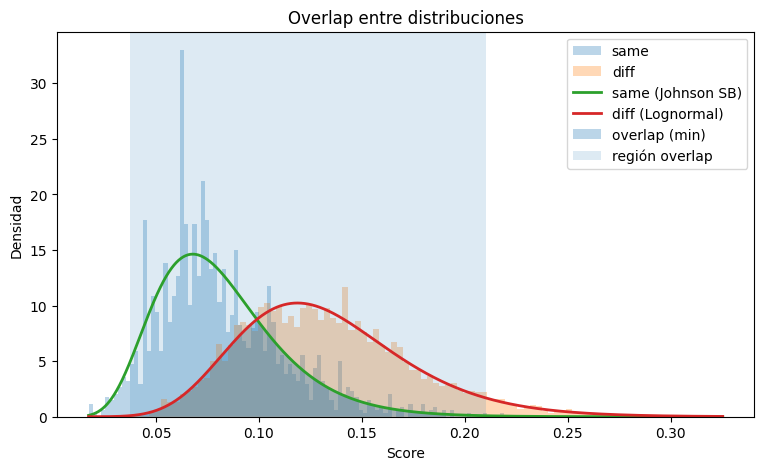

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Datos
# =========================
same_arr = np.array(same)
diff_arr = np.array(diff)

# limpiar
same_arr = same_arr[~np.isnan(same_arr)]
diff_arr = diff_arr[~np.isnan(diff_arr)]

# lognormal requiere positivos
diff_arr = diff_arr[diff_arr > 0]

# =========================
# 2. Ajustes
# =========================
params_jsb = stats.johnsonsb.fit(same_arr)
params_lognorm = stats.lognorm.fit(diff_arr)

# =========================
# 3. Rango común
# =========================
xmin = min(same_arr.min(), diff_arr.min())
xmax = max(same_arr.max(), diff_arr.max())

x = np.linspace(xmin, xmax, 2000)

# =========================
# 4. Densidades
# =========================
p_same = stats.johnsonsb.pdf(x, *params_jsb)
p_diff = stats.lognorm.pdf(x, *params_lognorm)

# =========================
# 5. Overlap (mínimo)
# =========================
p_min = np.minimum(p_same, p_diff)

# evitar ruido numérico
epsilon = 0.01 * p_min.max()

mask = p_min > epsilon
x_overlap = x[mask]

# =========================
# 6. Intervalo de cruce
# =========================
xmin_overlap = x_overlap.min()
xmax_overlap = x_overlap.max()

print("Región overlap:", xmin_overlap, xmax_overlap)

# =========================
# 7. Extraer datos reales
# =========================
same_overlap = same_arr[
    (same_arr >= xmin_overlap) & (same_arr <= xmax_overlap)
]

diff_overlap = diff_arr[
    (diff_arr >= xmin_overlap) & (diff_arr <= xmax_overlap)
]

print("same overlap:", len(same_overlap))
print("diff overlap:", len(diff_overlap))

# =========================
# 8. Graficar
# =========================
plt.figure(figsize=(9,5))

# histogramas
plt.hist(same_arr, bins=100, density=True, alpha=0.3, label="same")
plt.hist(diff_arr, bins=100, density=True, alpha=0.3, label="diff")

# curvas
plt.plot(x, p_same, label="same (Johnson SB)", linewidth=2)
plt.plot(x, p_diff, label="diff (Lognormal)", linewidth=2)

# overlap
plt.fill_between(x, p_min, alpha=0.3, label="overlap (min)")

# umbral (si ya lo tienes)
# plt.axvline(tau_star, linestyle='--', label="τ*")

plt.axvspan(xmin_overlap, xmax_overlap, alpha=0.15, label="región overlap")

plt.legend()
plt.title("Overlap entre distribuciones")
plt.xlabel("Score")
plt.ylabel("Densidad")
plt.show()

             sumsquare_error           aic           bic    kl_div  \
fisk              177.522055 -43563.657896 -43542.026875  0.108984   
burr              177.877748 -43562.410305 -43533.568943  0.108700   
exponnorm         183.115493 -43624.317747 -43602.686726  0.097996   
mielke            184.011259 -43576.603239 -43547.761877  0.094055   
genlogistic       191.422860 -43623.301732 -43601.670710  0.093093   

             ks_statistic  ks_pvalue  
fisk             0.019451   0.001021  
burr             0.019660   0.000867  
exponnorm        0.017100   0.005701  
mielke           0.019416   0.001049  
genlogistic      0.021199   0.000246  


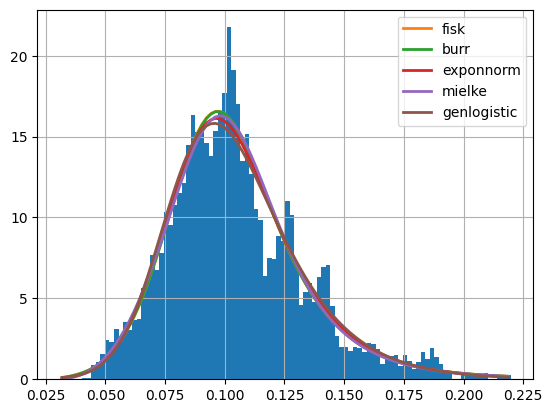

In [120]:
import numpy as np
from fitter import Fitter

# bins
bins = np.linspace(0, 0.5, 101)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2

# histogramas (densidad)
hist_same, _ = np.histogram(same, bins=bins, density=True)
hist_diff, _ = np.histogram(diff, bins=bins, density=True)

# overlap
hist_overlap = np.minimum(hist_same, hist_diff)

# convertir a probabilidad
p_overlap = hist_overlap * bin_width
p_overlap = p_overlap / np.sum(p_overlap)

# =========================
# reconstrucción CORRECTA
# =========================
n_samples = 10000

bin_idx = np.random.choice(len(bin_centers), size=n_samples, p=p_overlap)

overlap_data = np.random.uniform(
    bins[bin_idx],
    bins[bin_idx + 1]
)

# =========================
# usar fitter
# =========================
f = Fitter(
    overlap_data)

f.fit()

# resultados
print(f.summary())

In [121]:
for dist, params in f.fitted_param.items():
    print(f"{dist}: {params}")

alpha: (np.float64(8.503836357455478), np.float64(-0.12743835142454873), np.float64(1.9485042691710808))
anglit: (np.float64(1.2387139279376962), np.float64(4.0582684624507876e-33))
arcsine: (np.float64(0.030898773588889632), np.float64(0.18890922787946116))
argus: (np.float64(0.007923677198758299), np.float64(0.003973628748241013), np.float64(0.21584476861959545))
beta: (np.float64(8.962837440581737), np.float64(1185.4125557216803), np.float64(0.01948386631234976), np.float64(11.400089903287657))
betaprime: (np.float64(64.56905314838328), np.float64(33.966177762771935), np.float64(-0.026157742152316615), np.float64(0.06695924409127206))
bradford: (np.float64(0.8753110350540209), np.float64(0.030905026962705133), np.float64(0.18890297519074384))
burr: (np.float64(6.587955318310424), np.float64(0.9470045830370672), np.float64(0.0016841021510414168), np.float64(0.10098582432850742))
burr12: (np.float64(3.9829999445985598), np.float64(1.8498177506540416), np.float64(0.02705340468124217), 

           sumsquare_error          aic          bic    kl_div  ks_statistic  \
fisk            372.209236 -4334.592177 -4319.868911  0.151606      0.026653   
burr            372.421209 -4332.809337 -4313.178316  0.149310      0.027106   
exponnorm       381.665262 -4339.893314 -4325.170048  0.144565      0.022854   
mielke          396.496345 -4338.436052 -4318.805031  0.144050      0.025196   
johnsonsb       435.442608 -4334.799126 -4315.168105  0.128659      0.031162   

           ks_pvalue  
fisk        0.468272  
burr        0.446702  
exponnorm   0.664449  
mielke      0.540924  
johnsonsb   0.280121  


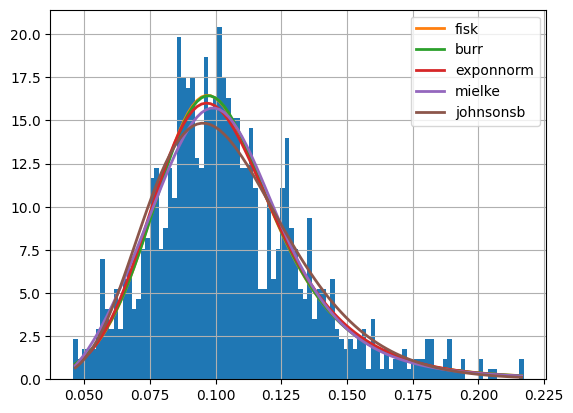

In [122]:
import numpy as np
from fitter import Fitter

# bins
bins = np.linspace(0, 0.5, 101)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2

# histogramas (densidad)
hist_same, _ = np.histogram(same, bins=bins, density=True)
hist_diff, _ = np.histogram(diff, bins=bins, density=True)

# overlap
hist_overlap = np.minimum(hist_same, hist_diff)

# convertir a probabilidad
p_overlap = hist_overlap * bin_width
p_overlap = p_overlap / np.sum(p_overlap)

# =========================
# reconstrucción CORRECTA
# =========================
n_samples = 1000

bin_idx = np.random.choice(len(bin_centers), size=n_samples, p=p_overlap)

overlap_data = np.random.uniform(
    bins[bin_idx],
    bins[bin_idx + 1]
)

# =========================
# usar fitter
# =========================
f = Fitter(
    overlap_data,
    distributions=['fisk', 'burr', 'exponnorm', 'mielke', 'genlogistic'
        'lognorm',
        'gamma',
        'beta',
        'johnsonsb',
        'norm'
    ]
)

f.fit()

# resultados
print(f.summary())

In [123]:
for dist, params in f.fitted_param.items():
    print(f"{dist}: {params}")

fisk: (np.float64(6.650213733581145), np.float64(-0.0017974411721936785), np.float64(0.10333781179124038))
burr: (np.float64(6.559049234952937), np.float64(0.9366197146825739), np.float64(0.0018635309520200049), np.float64(0.10115047162243511))
exponnorm: (np.float64(1.2907888261075486), np.float64(0.08199810575317731), np.float64(0.017933991138717492))
mielke: (np.float64(2.6018255238949557), np.float64(5.239694323917887), np.float64(0.0391742430257151), np.float64(0.07757151420699833))
gamma: (np.float64(8.48739011445199), np.float64(0.02138251011866819), np.float64(0.009869299889325533))
beta: (np.float64(8.487374148458702), np.float64(45566357.57563101), np.float64(0.021382534354278594), np.float64(449708.96916390955))
johnsonsb: (np.float64(11.288195538882547), np.float64(3.7362562699275585), np.float64(-0.006736008618298907), np.float64(2.334470310223799))
norm: (np.float64(0.10514712669752413), np.float64(0.02893672356002156))


In [116]:
hist_overlap

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.02208359, 0.        , 0.05520897, 0.54104787,
       1.03792856, 1.22563904, 1.73356153, 2.70523933, 3.2462872 ,
       4.90255618, 5.69756528, 7.23237454, 7.01545779, 7.34279247,
       9.03686088, 6.77764566, 5.11296076, 3.3293698 , 3.80499405,
       4.39952438, 2.49702735, 2.49702735, 2.97265161, 1.07015458,
       0.95124851, 0.83234245, 0.95124851, 0.59453032, 0.47562426,
       0.47562426, 0.59453032, 0.59453032, 0.35671819, 0.        ,
       0.11890606, 0.11890606, 0.        , 0.11890606, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
geninvgauss,1786.919051,180.841503,208.681833,inf,0.043483,3.136527e-13
recipinvgauss,1787.614439,173.916691,194.796938,inf,0.043191,4.655115e-13
fatiguelife,1788.492182,169.848773,190.729020,inf,0.043172,4.775525e-13
gengamma,1789.697911,164.042109,191.882439,inf,0.045328,2.435459e-14
johnsonsb,1789.974620,166.293994,194.134324,inf,0.044103,1.344197e-13


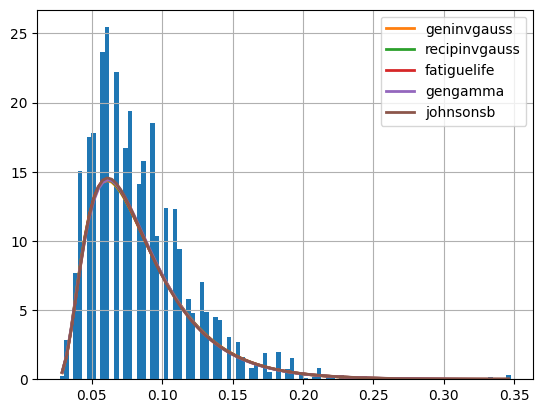

In [ ]:
from fitter import Fitter

data = overlap_data

f = Fitter(data)   # no especificas distribuciones
f.fit()

f.summary()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
geninvgauss,1786.919051,180.841503,208.681833,inf,0.043483,3.136527e-13
recipinvgauss,1787.614439,173.916691,194.796938,inf,0.043191,4.655115e-13
gengamma,1789.697911,164.042109,191.882439,inf,0.045328,2.435459e-14
johnsonsb,1789.974620,166.293994,194.134324,inf,0.044103,1.344197e-13
lognorm,1796.334600,138.567042,159.447289,inf,0.046725,3.279132e-15


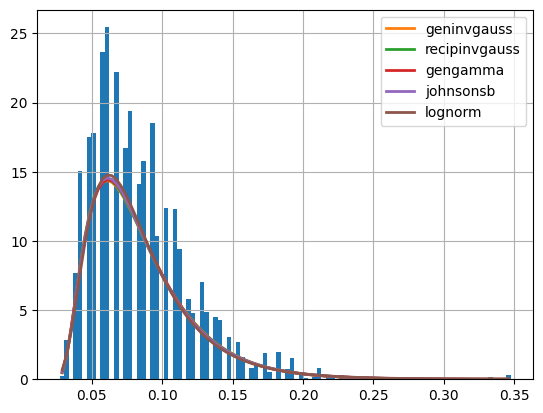

In [ ]:
from fitter import Fitter

data = overlap_data

f = Fitter(data, distributions=['geninvgauss', 'recipinvgauss',
                                #'fatiguelife',
                                'gengamma', 'johnsonsb', 'lognorm'])   # no especificas distribuciones
f.fit()

f.summary()

In [ ]:
len(same)

NameError: name 'same' is not defined

In [ ]:
from scipy.stats import anderson

log_data = np.log(diff)

res = anderson(log_data, dist='norm')

/tmp/ipykernel_85894/2207990328.py:5: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = anderson(log_data, dist='norm')


In [ ]:
print(res.statistic)
print(res.critical_values)

223.33196939365007
[0.561 0.631 0.752 0.873 1.035]


In [ ]:
#scaterplot

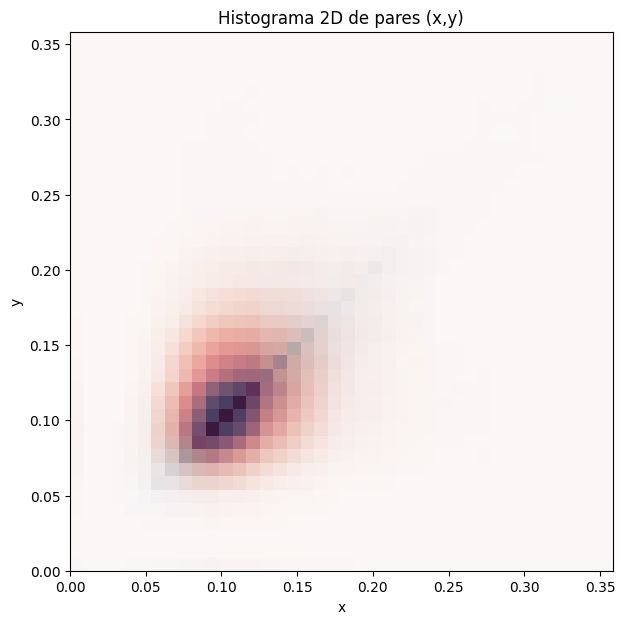

In [ ]:

import matplotlib.pyplot as plt
from itertools import combinations

same_x = []
same_y = []

diff_x = []
diff_y = []

for col1, col2 in combinations(df.columns, 2):

    pref1 = col1[:2]
    pref2 = col2[:2]

    x = df[col1]
    y = df[col2]

    if pref1 == pref2:
        same_x.extend(x)
        same_y.extend(y)
    else:
        diff_x.extend(x)
        diff_y.extend(y)

plt.figure(figsize=(7,7))

plt.hist2d(same_x, same_y, bins=40, cmap="Blues")
plt.hist2d(diff_x, diff_y, bins=40, cmap="Reds", alpha=0.5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Histograma 2D de pares (x,y)")

plt.show()

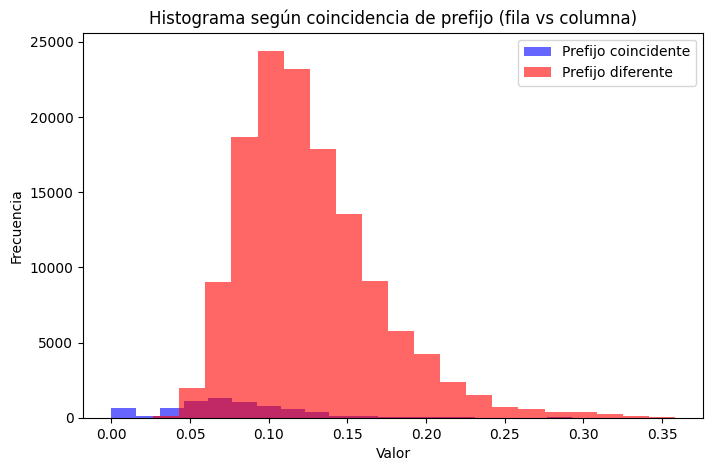

In [ ]:
import matplotlib.pyplot as plt

same_prefix_values = []
diff_prefix_values = []

# recorrer filas y columnas
for fila in df.index:
    for col in df.columns:
        pref_fila = str(fila)[:2]  # prefijo de la fila
        pref_col = str(col)[:2]    # prefijo de la columna

        value = df.loc[fila, col]

        if pref_fila == pref_col:
            same_prefix_values.append(value)
        else:
            diff_prefix_values.append(value)

# graficar un histograma único
plt.figure(figsize=(8,5))
plt.hist(same_prefix_values, bins=20, alpha=0.6, color='blue', label='Prefijo coincidente')
plt.hist(diff_prefix_values, bins=20, alpha=0.6, color='red', label='Prefijo diferente')
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.title("Histograma según coincidencia de prefijo (fila vs columna)")
plt.legend()
plt.show()

In [ ]:
same_prefix_values = []
diff_prefix_values = []

# recorrer filas y columnas
for fila in df.index:
    for col in df.columns:

        # descartar claves idénticas
        #se puede omitir si se quiere la barra de la izquierda
        if fila == col:
            continue

        pref_fila = str(fila)[:2]
        pref_col = str(col)[:2]

        value = df.loc[fila, col]

        if pref_fila == pref_col:
            same_prefix_values.append(value)
        else:
            diff_prefix_values.append(value)

same_prefix_values = np.array(same_prefix_values)
diff_prefix_values = np.array(diff_prefix_values)

same = np.array(same_prefix_values)
diff = np.array(diff_prefix_values)

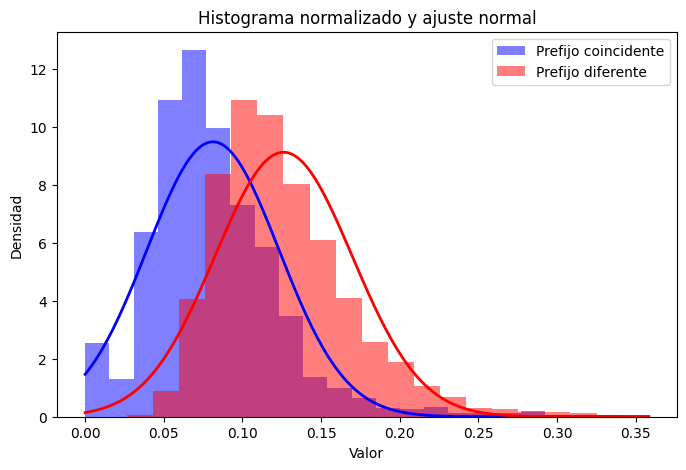


Ajuste Normal - Prefijo coincidente
KS statistic = 0.0807
p-value = 9.0252e-39

Ajuste Normal - Prefijo diferente
KS statistic = 0.0782
p-value = 0.0000e+00

Comparación entre prefijo coincidente y diferente
KS statistic = 0.4669
p-value = 0.0000e+00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, kstest, ks_2samp

plt.figure(figsize=(8,5))

# histogramas normalizados
plt.hist(same_prefix_values, bins=20, density=True, alpha=0.5,
         color='blue', label='Prefijo coincidente')

plt.hist(diff_prefix_values, bins=20, density=True, alpha=0.5,
         color='red', label='Prefijo diferente')

# ----------------------------
# Ajuste normal
# ----------------------------
mu1, std1 = norm.fit(same_prefix_values)
mu2, std2 = norm.fit(diff_prefix_values)

xmin = min(same_prefix_values.min(), diff_prefix_values.min())
xmax = max(same_prefix_values.max(), diff_prefix_values.max())
x = np.linspace(xmin, xmax, 200)

# curvas normales
p1 = norm.pdf(x, mu1, std1)
p2 = norm.pdf(x, mu2, std2)

plt.plot(x, p1, 'b-', linewidth=2)
plt.plot(x, p2, 'r-', linewidth=2)

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Histograma normalizado y ajuste normal")
plt.legend()
plt.show()


# ----------------------------
# Test KS de ajuste a Normal
# ----------------------------

ks_same = kstest(same_prefix_values, 'norm', args=(mu1, std1))
ks_diff = kstest(diff_prefix_values, 'norm', args=(mu2, std2))

print("\nAjuste Normal - Prefijo coincidente")
print(f"KS statistic = {ks_same.statistic:.4f}")
print(f"p-value = {ks_same.pvalue:.4e}")

print("\nAjuste Normal - Prefijo diferente")
print(f"KS statistic = {ks_diff.statistic:.4f}")
print(f"p-value = {ks_diff.pvalue:.4e}")


# ----------------------------
# Test KS entre las dos muestras
# ----------------------------

ks_between = ks_2samp(same_prefix_values, diff_prefix_values)

print("\nComparación entre prefijo coincidente y diferente")
print(f"KS statistic = {ks_between.statistic:.4f}")
print(f"p-value = {ks_between.pvalue:.4e}")

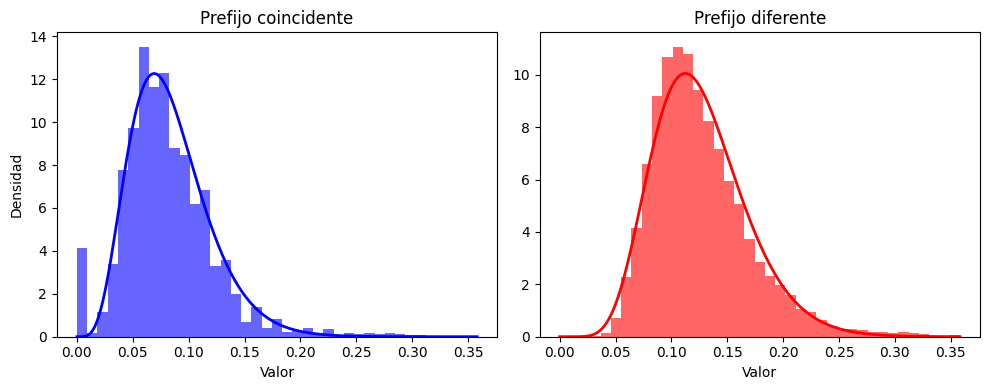

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2


xmin = min(same.min(), diff.min())
xmax = max(same.max(), diff.max())

bins = np.linspace(xmin, xmax, 40)
x = np.linspace(xmin, xmax, 400)

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharex=True)

# ---- prefijos iguales ----
axes[0].hist(same, bins=bins, density=True, alpha=0.6, color="blue")
df1, loc1, scale1 = chi2.fit(same, floc=0)
axes[0].plot(x, chi2.pdf(x, df1, loc1, scale1), "b-", lw=2)
axes[0].set_title("Prefijo coincidente")
axes[0].set_ylabel("Densidad")

# ---- prefijos diferentes ----
axes[1].hist(diff, bins=bins, density=True, alpha=0.6, color="red")
df2, loc2, scale2 = chi2.fit(diff, floc=0)
axes[1].plot(x, chi2.pdf(x, df2, loc2, scale2), "r-", lw=2)
axes[1].set_title("Prefijo diferente")

for ax in axes:
    ax.set_xlabel("Valor")

plt.tight_layout()
plt.show()

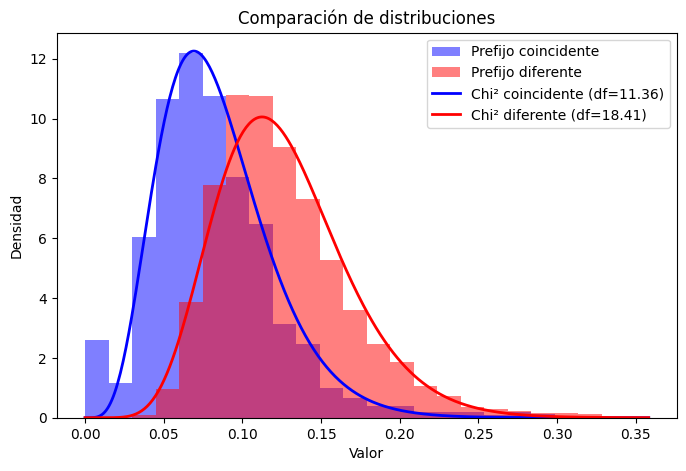

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

same = np.array(same_prefix_values)
diff = np.array(diff_prefix_values)

# usar todos los datos para definir bins
all_values = np.concatenate([same, diff])
bins = np.histogram_bin_edges(all_values, bins=40)

x = np.linspace(all_values.min(), all_values.max(), 400)

###
xmin = min(same.min(), diff.min())
xmax = max(same.max(), diff.max())

bins = np.linspace(xmin, xmax, 25)
x = np.linspace(xmin, xmax, 400)
###


plt.figure(figsize=(8,5))

plt.hist(same, bins=bins, density=True, alpha=0.5,
         color="blue", label="Prefijo coincidente")

plt.hist(diff, bins=bins, density=True, alpha=0.5,
         color="red", label="Prefijo diferente")

# ajuste chi²
df1, loc1, scale1 = chi2.fit(same, floc=0)
df2, loc2, scale2 = chi2.fit(diff, floc=0)

plt.plot(x, chi2.pdf(x, df1, loc1, scale1),
         "b-", lw=2, label=f"Chi² coincidente (df={df1:.2f})")

plt.plot(x, chi2.pdf(x, df2, loc2, scale2),
         "r-", lw=2, label=f"Chi² diferente (df={df2:.2f})")

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Comparación de distribuciones")
plt.legend()

plt.show()





In [ ]:
from scipy.stats import kstest, ks_2samp

# ----------------------------
# Test KS de ajuste a Chi²
# ----------------------------

ks_same = kstest(same, 'chi2', args=(df1, loc1, scale1))
ks_diff = kstest(diff, 'chi2', args=(df2, loc2, scale2))

print("\nAjuste Chi² - Prefijo coincidente")
print(f"KS statistic = {ks_same.statistic:.4f}")
print(f"p-value = {ks_same.pvalue:.4e}")

print("\nAjuste Chi² - Prefijo diferente")
print(f"KS statistic = {ks_diff.statistic:.4f}")
print(f"p-value = {ks_diff.pvalue:.4e}")

# ----------------------------
# Test KS entre las dos muestras
# ----------------------------

ks_between = ks_2samp(same, diff)

print("\nComparación entre prefijo coincidente y diferente")
print(f"KS statistic = {ks_between.statistic:.4f}")
print(f"p-value = {ks_between.pvalue:.4e}")


Ajuste Chi² - Prefijo coincidente
KS statistic = 0.0512
p-value = 7.1370e-16

Ajuste Chi² - Prefijo diferente
KS statistic = 0.0346
p-value = 2.3792e-140

Comparación entre prefijo coincidente y diferente
KS statistic = 0.4669
p-value = 0.0000e+00


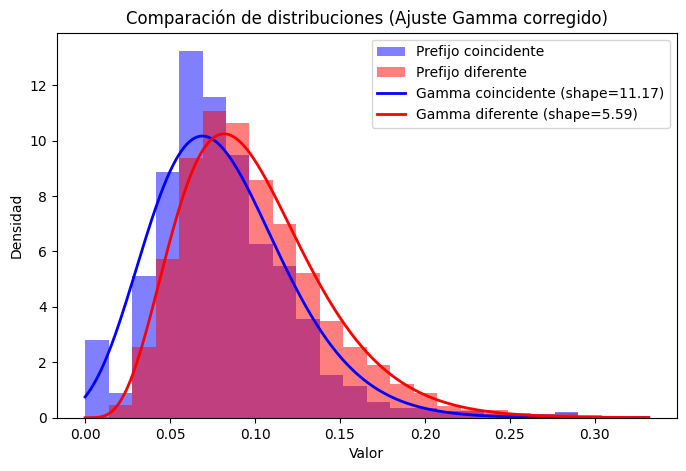


Ajuste Gamma - Prefijo coincidente
KS statistic = 0.0490
p-value = 1.5410e-14

Ajuste Gamma - Prefijo diferente
KS statistic = 0.0221
p-value = 3.1562e-57

Comparación entre prefijo coincidente y diferente
KS statistic = 0.1867
p-value = 4.2681e-197


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma, kstest, ks_2samp

same = np.array(same_prefix_values)
diff = np.array(diff_prefix_values)

# ----------------------------
# Desplazar datos para que sean positivos
# ----------------------------
same_pos = same - same.min() + 1e-6
diff_pos = diff - diff.min() + 1e-6

# rango y bins
all_values = np.concatenate([same_pos, diff_pos])
xmin = all_values.min()
xmax = all_values.max()
bins = np.linspace(xmin, xmax, 25)
x = np.linspace(xmin, xmax, 400)

plt.figure(figsize=(8,5))

# histogramas
plt.hist(same_pos, bins=bins, density=True, alpha=0.5,
         color="blue", label="Prefijo coincidente")
plt.hist(diff_pos, bins=bins, density=True, alpha=0.5,
         color="red", label="Prefijo diferente")

# ----------------------------
# Ajuste Gamma
# ----------------------------
shape1, loc1, scale1 = gamma.fit(same_pos)
shape2, loc2, scale2 = gamma.fit(diff_pos)

plt.plot(x, gamma.pdf(x, shape1, loc1, scale1),
         "b-", lw=2, label=f"Gamma coincidente (shape={shape1:.2f})")
plt.plot(x, gamma.pdf(x, shape2, loc2, scale2),
         "r-", lw=2, label=f"Gamma diferente (shape={shape2:.2f})")

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Comparación de distribuciones (Ajuste Gamma corregido)")
plt.legend()
plt.show()

# ----------------------------
# Test KS de ajuste Gamma
# ----------------------------
ks_same = kstest(same_pos, 'gamma', args=(shape1, loc1, scale1))
ks_diff = kstest(diff_pos, 'gamma', args=(shape2, loc2, scale2))

# ----------------------------
# Test KS entre las dos muestras
# ----------------------------
ks_between = ks_2samp(same_pos, diff_pos)

print("\nAjuste Gamma - Prefijo coincidente")
print(f"KS statistic = {ks_same.statistic:.4f}")
print(f"p-value = {ks_same.pvalue:.4e}")

print("\nAjuste Gamma - Prefijo diferente")
print(f"KS statistic = {ks_diff.statistic:.4f}")
print(f"p-value = {ks_diff.pvalue:.4e}")

print("\nComparación entre prefijo coincidente y diferente")
print(f"KS statistic = {ks_between.statistic:.4f}")
print(f"p-value = {ks_between.pvalue:.4e}")

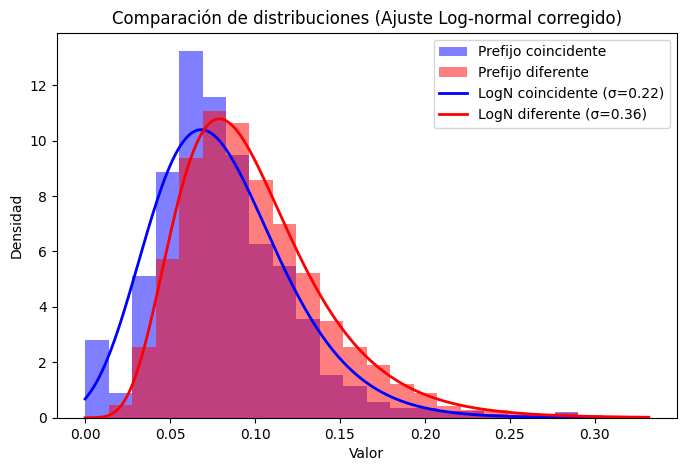


Ajuste Log-normal - Prefijo coincidente
KS statistic = 0.0455
p-value = 1.3523e-12

Ajuste Log-normal - Prefijo diferente
KS statistic = 0.0071
p-value = 3.0279e-06

Comparación entre prefijo coincidente y diferente
KS statistic = 0.1867
p-value = 4.2681e-197


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm, kstest, ks_2samp

same = np.array(same_prefix_values)
diff = np.array(diff_prefix_values)

# desplazar los datos para que sean positivos
same_pos = same - same.min() + 1e-6
diff_pos = diff - diff.min() + 1e-6

# definir bins y rango
all_values = np.concatenate([same_pos, diff_pos])
xmin = all_values.min()
xmax = all_values.max()
bins = np.linspace(xmin, xmax, 25)
x = np.linspace(xmin, xmax, 400)

plt.figure(figsize=(8,5))

# histogramas
plt.hist(same_pos, bins=bins, density=True, alpha=0.5,
         color="blue", label="Prefijo coincidente")
plt.hist(diff_pos, bins=bins, density=True, alpha=0.5,
         color="red", label="Prefijo diferente")

# ----------------------------
# Ajuste Log-normal sin fijar loc
# ----------------------------
shape1, loc1, scale1 = lognorm.fit(same_pos)
shape2, loc2, scale2 = lognorm.fit(diff_pos)

plt.plot(x, lognorm.pdf(x, shape1, loc1, scale1),
         "b-", lw=2, label=f"LogN coincidente (σ={shape1:.2f})")
plt.plot(x, lognorm.pdf(x, shape2, loc2, scale2),
         "r-", lw=2, label=f"LogN diferente (σ={shape2:.2f})")

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Comparación de distribuciones (Ajuste Log-normal corregido)")
plt.legend()
plt.show()

# ----------------------------
# Test KS de ajuste Log-normal
# ----------------------------
ks_same = kstest(same_pos, 'lognorm', args=(shape1, loc1, scale1))
ks_diff = kstest(diff_pos, 'lognorm', args=(shape2, loc2, scale2))

# ----------------------------
# Test KS entre las dos muestras
# ----------------------------
ks_between = ks_2samp(same_pos, diff_pos)

print("\nAjuste Log-normal - Prefijo coincidente")
print(f"KS statistic = {ks_same.statistic:.4f}")
print(f"p-value = {ks_same.pvalue:.4e}")

print("\nAjuste Log-normal - Prefijo diferente")
print(f"KS statistic = {ks_diff.statistic:.4f}")
print(f"p-value = {ks_diff.pvalue:.4e}")

print("\nComparación entre prefijo coincidente y diferente")
print(f"KS statistic = {ks_between.statistic:.4f}")
print(f"p-value = {ks_between.pvalue:.4e}")

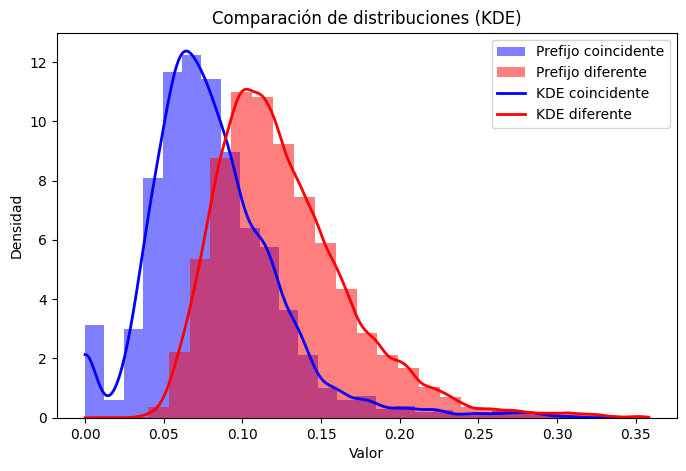


Comparación entre prefijo coincidente y diferente (KDE/empírico)
KS statistic = 0.4669
p-value = 0.0000e+00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde, ks_2samp

same = np.array(same_prefix_values)
diff = np.array(diff_prefix_values)

# ----------------------------
# Desplazar los datos para que sean positivos (opcional si KDE necesita)
# ----------------------------
# KDE funciona con cualquier valor, solo para fines de comparación podemos dejar igual
same_kde = same
diff_kde = diff

# rango para graficar
xmin = min(same_kde.min(), diff_kde.min())
xmax = max(same_kde.max(), diff_kde.max())
x = np.linspace(xmin, xmax, 400)

plt.figure(figsize=(8,5))

# histogramas
plt.hist(same_kde, bins=25, density=True, alpha=0.5,
         color="blue", label="Prefijo coincidente")
plt.hist(diff_kde, bins=25, density=True, alpha=0.5,
         color="red", label="Prefijo diferente")

# ----------------------------
# KDE
# ----------------------------
kde_same = gaussian_kde(same_kde)
kde_diff = gaussian_kde(diff_kde)

plt.plot(x, kde_same(x), "b-", lw=2, label="KDE coincidente")
plt.plot(x, kde_diff(x), "r-", lw=2, label="KDE diferente")

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Comparación de distribuciones (KDE)")
plt.legend()
plt.show()

# ----------------------------
# Test KS entre los dos grupos
# ----------------------------
ks_between = ks_2samp(same_kde, diff_kde)

print("\nComparación entre prefijo coincidente y diferente (KDE/empírico)")
print(f"KS statistic = {ks_between.statistic:.4f}")
print(f"p-value = {ks_between.pvalue:.4e}")

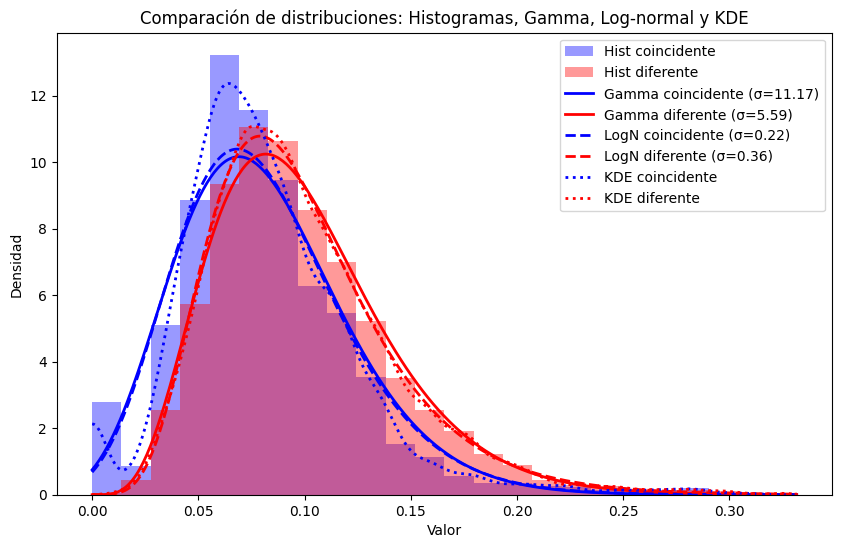

===== Test KS =====

Gamma - Prefijo coincidente: KS = 0.0490, p = 1.5410e-14
Gamma - Prefijo diferente:   KS = 0.0221, p = 3.1562e-57
Log-normal - Prefijo coincidente: KS = 0.0455, p = 1.3523e-12
Log-normal - Prefijo diferente:   KS = 0.0071, p = 3.0279e-06
Comparación entre prefijo coincidente y diferente (empírico/KDE): KS = 0.1867, p = 4.2681e-197


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma, lognorm, gaussian_kde, ks_2samp, kstest

same = np.array(same_prefix_values)
diff = np.array(diff_prefix_values)

# ----------------------------
# Desplazar datos positivos para ajustes paramétricos
# ----------------------------
same_pos = same - same.min() + 1e-6
diff_pos = diff - diff.min() + 1e-6

# ----------------------------
# Rango y bins
# ----------------------------
all_values = np.concatenate([same_pos, diff_pos])
xmin = all_values.min()
xmax = all_values.max()
bins = np.linspace(xmin, xmax, 25)
x = np.linspace(xmin, xmax, 400)

plt.figure(figsize=(10,6))

# ----------------------------
# Histogramas
# ----------------------------
plt.hist(same_pos, bins=bins, density=True, alpha=0.4,
         color="blue", label="Hist coincidente")
plt.hist(diff_pos, bins=bins, density=True, alpha=0.4,
         color="red", label="Hist diferente")

# ----------------------------
# Ajuste Gamma
# ----------------------------
shape1_g, loc1_g, scale1_g = gamma.fit(same_pos)
shape2_g, loc2_g, scale2_g = gamma.fit(diff_pos)

plt.plot(x, gamma.pdf(x, shape1_g, loc1_g, scale1_g), "b-", lw=2,
         label=f"Gamma coincidente (σ={shape1_g:.2f})")
plt.plot(x, gamma.pdf(x, shape2_g, loc2_g, scale2_g), "r-", lw=2,
         label=f"Gamma diferente (σ={shape2_g:.2f})")

# ----------------------------
# Ajuste Log-normal
# ----------------------------
shape1_ln, loc1_ln, scale1_ln = lognorm.fit(same_pos)
shape2_ln, loc2_ln, scale2_ln = lognorm.fit(diff_pos)

plt.plot(x, lognorm.pdf(x, shape1_ln, loc1_ln, scale1_ln), "b--", lw=2,
         label=f"LogN coincidente (σ={shape1_ln:.2f})")
plt.plot(x, lognorm.pdf(x, shape2_ln, loc2_ln, scale2_ln), "r--", lw=2,
         label=f"LogN diferente (σ={shape2_ln:.2f})")

# ----------------------------
# KDE
# ----------------------------
kde_same = gaussian_kde(same_pos)
kde_diff = gaussian_kde(diff_pos)

plt.plot(x, kde_same(x), "b:", lw=2, label="KDE coincidente")
plt.plot(x, kde_diff(x), "r:", lw=2, label="KDE diferente")

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Comparación de distribuciones: Histogramas, Gamma, Log-normal y KDE")
plt.legend()
plt.show()

# ----------------------------
# Tests KS
# ----------------------------
ks_gamma_same = kstest(same_pos, 'gamma', args=(shape1_g, loc1_g, scale1_g))
ks_gamma_diff = kstest(diff_pos, 'gamma', args=(shape2_g, loc2_g, scale2_g))
ks_lognorm_same = kstest(same_pos, 'lognorm', args=(shape1_ln, loc1_ln, scale1_ln))
ks_lognorm_diff = kstest(diff_pos, 'lognorm', args=(shape2_ln, loc2_ln, scale2_ln))
ks_between = ks_2samp(same_pos, diff_pos)

print("===== Test KS =====\n")
print("Gamma - Prefijo coincidente: KS = {:.4f}, p = {:.4e}".format(ks_gamma_same.statistic, ks_gamma_same.pvalue))
print("Gamma - Prefijo diferente:   KS = {:.4f}, p = {:.4e}".format(ks_gamma_diff.statistic, ks_gamma_diff.pvalue))
print("Log-normal - Prefijo coincidente: KS = {:.4f}, p = {:.4e}".format(ks_lognorm_same.statistic, ks_lognorm_same.pvalue))
print("Log-normal - Prefijo diferente:   KS = {:.4f}, p = {:.4e}".format(ks_lognorm_diff.statistic, ks_lognorm_diff.pvalue))
print("Comparación entre prefijo coincidente y diferente (empírico/KDE): KS = {:.4f}, p = {:.4e}".format(ks_between.statistic, ks_between.pvalue))

In [ ]:
same_prefix_values

array([71.73600985, 60.60074826, 66.29195899, ..., 60.92214797,
       32.9083346 , 67.82920206])

In [ ]:
name_img="CF/5.jpg"
Add_Features_Dictionary(name_img)

In [ ]:
Features_Dictionary

{'CF/5.jpg': [np.float64(121.22098521710916),
  np.float64(110.97042667819753),
  np.float64(54.47675061014001),
  np.float64(41.96830762232807),
  np.float64(222.1331739866302),
  np.float64(167.87708125014498),
  np.float64(43.984093625437964),
  np.float64(33.89888830500795),
  np.float64(67.64082745451842),
  np.float64(87.49553778703108),
  np.float64(21.578825360066578),
  np.float64(14.77305509247073),
  np.float64(161.6007331230295),
  np.float64(153.10304527134713),
  np.float64(28.117385841671897),
  np.float64(29.402531183716373),
  np.float64(54.09058822955585),
  np.float64(101.15918535757864),
  np.float64(5.829721227182208),
  np.float64(3.7763929758807646),
  np.float64(169.69598272758392),
  np.float64(159.4092043910806),
  np.float64(7.135909346094847),
  np.float64(5.0561206533461975),
  np.float64(22.429763869526738),
  np.float64(45.132030203475466),
  np.float64(2.1449248584574887),
  np.float64(1.6526542413313476),
  np.float64(73.54378191869407),
  np.float64(69

In [ ]:
claves=['R/18.jpg',
 'R/17.jpg',
 'S/17.jpg',
 'S/12.jpg',
 'EL/12.jpg',
 'EL/2.jpg',
 'AL/8.jpg',
 'AL/4.jpg',
 'BR/4.jpg',
 'BR/12.jpg',
 'A/12.jpg',
 'A/8.jpg',
 'BI/4.jpg',
 'BI/17.jpg',
 'CF/11.jpg',
 'CF/5.jpg']

In [ ]:
for name_img in claves:
  Add_Features_Dictionary(name_img)

In [ ]:
claves = list(Features_Dictionary.keys())
claves

['CF/5.jpg',
 'R/18.jpg',
 'R/17.jpg',
 'S/17.jpg',
 'S/12.jpg',
 'EL/12.jpg',
 'EL/2.jpg',
 'AL/8.jpg',
 'AL/4.jpg',
 'BR/4.jpg',
 'BR/12.jpg',
 'A/12.jpg',
 'A/8.jpg',
 'BI/4.jpg',
 'BI/17.jpg',
 'CF/11.jpg']

In [ ]:
Features_Dictionary

{'CF/5.jpg': [np.float64(121.22098521710916),
  np.float64(110.97042667819753),
  np.float64(54.47675061014001),
  np.float64(41.96830762232807),
  np.float64(222.1331739866302),
  np.float64(167.87708125014498),
  np.float64(43.984093625437964),
  np.float64(33.89888830500795),
  np.float64(67.64082745451842),
  np.float64(87.49553778703108),
  np.float64(21.578825360066578),
  np.float64(14.77305509247073),
  np.float64(161.6007331230295),
  np.float64(153.10304527134713),
  np.float64(28.117385841671897),
  np.float64(29.402531183716373),
  np.float64(54.09058822955585),
  np.float64(101.15918535757864),
  np.float64(5.829721227182208),
  np.float64(3.7763929758807646),
  np.float64(169.69598272758392),
  np.float64(159.4092043910806),
  np.float64(7.135909346094847),
  np.float64(5.0561206533461975),
  np.float64(22.429763869526738),
  np.float64(45.132030203475466),
  np.float64(2.1449248584574887),
  np.float64(1.6526542413313476),
  np.float64(73.54378191869407),
  np.float64(69

In [ ]:
Test_Dictionary={}

In [ ]:
def Add_Test_Dictionary(name_image):
    """
    Genera un vector
    """

    name_img=name_image
    img_pixels = cv.imread('/kaggle/input/multimodal-biometric-dataset-mulb/MULB dataset/iris dataset/'+name_img, cv.IMREAD_GRAYSCALE)
    if img_pixels is None:
      return

    iris_pipeline = iris.IRISPipeline(env=iris.IRISPipeline.DEBUGGING_ENVIRONMENT)

    output = iris_pipeline(iris.IRImage(img_data=img_pixels, image_id="image_id", eye_side="right"))
    iris_visualizer = iris.visualisation.IRISVisualizer()


    out = iris_visualizer.plot_normalized_iris(normalized_iris=iris_pipeline.call_trace['normalization'],)

    plt.savefig("iris_normalized.png", dpi=300, bbox_inches="tight")
    plt.close()

    Features_Vector = []
    # Leer imagen en escala de grises
    img = cv.imread("iris_normalized.png", cv.IMREAD_GRAYSCALE)
    img = img.astype(np.float64) / 255.0
    # Visualización
    fig, axes = plt.subplots(
        len(thetas),
        len(phis),
        figsize=(12, 8),
        sharex=True,
        sharey=True
    )
    for i, theta in enumerate(thetas):
        for j, phi in enumerate(phis):
            # Construir kernel
            kernel = gabor_kernel(theta, phi, sigma)
            # Aplicar filtro
            response = apply_gabor(img, kernel)
            # Normalizar respuesta
            response_norm = response / (response.max() + 1e-8)
            ax = axes[i, j]
            ax.imshow(response_norm, cmap='gray')
            ax.axis('off')
            # Títulos solo en bordes (más limpio)
            ax.set_title(rf"$\theta = {theta},\ \varphi = {j}\pi/4,\mu_c = {round(response.mean(),3)},\sigma_c = {round(response.std(),3)} $", fontsize=9)
            Features_Vector.append(response.mean())
            Features_Vector.append(response.std())
    plt.suptitle(
        rf"Banco de filtros de Gabor (3 frecuencias × 4 orientaciones){name_img}",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(name_img.replace("/", "_"))
    plt.close()

    # Guardamos las caracteristicas en el diccionario
    Test_Dictionary[name_image] = Features_Vector


In [ ]:

claves_test=['R/15.jpg',
 'S/14.jpg',
 'EL/6.jpg',
 'AL/7.jpg',
 'BR/10.jpg', 'AW/10.jpg']


In [ ]:
#Add_Test_Dictionary('AW/10.jpg')

In [ ]:
for name_img in claves_test:
  Add_Test_Dictionary(name_img)

In [ ]:
Test_Dictionary

{'R/15.jpg': [np.float64(114.90957836307739),
  np.float64(101.11422951648665),
  np.float64(52.29778184687757),
  np.float64(36.34772899263631),
  np.float64(233.5798538510145),
  np.float64(155.95358278122202),
  np.float64(57.666820895781214),
  np.float64(58.83846292026786),
  np.float64(72.72159724381079),
  np.float64(80.19046741895978),
  np.float64(25.660796813105417),
  np.float64(17.99031094506906),
  np.float64(177.27963356220792),
  np.float64(153.22947786237145),
  np.float64(23.35996305946204),
  np.float64(17.30497630977656),
  np.float64(55.9231746132823),
  np.float64(103.73058378566452),
  np.float64(9.698520231112498),
  np.float64(6.8922961605819255),
  np.float64(170.24672976471905),
  np.float64(160.15145044013943),
  np.float64(8.668085479571628),
  np.float64(5.362047364451783),
  np.float64(21.864444095963925),
  np.float64(41.602947892411336),
  np.float64(2.853966649210705),
  np.float64(2.2511795604489007),
  np.float64(71.84667437830875),
  np.float64(67.88

In [ ]:

df = pd.DataFrame(index=claves, columns=claves_test)

for i in claves:
    for j in claves_test:
        df.loc[i, j] = distancia_euclidiana(Features_Dictionary, Test_Dictionary, i, j)

for col in df.columns:
    orden = df[col].sort_values(ascending=True)
    print(f"Columna {col}:")
    print(orden)
    print()
coincidencias = {}

for col in df.columns:
    # ordenamos la columna ascendente y obtenemos los índices
    indices_ordenados = df[col].sort_values(ascending=True).index

    # tomamos los dos primeros caracteres de la columna
    prefix_col = col[:2]

    # tomamos los dos primeros índices de la columna ordenada
    primeros_indices = indices_ordenados[:3]

    # contamos cuántos coinciden en los dos primeros caracteres
    count = sum(1 for idx in primeros_indices if idx[:2] == prefix_col)

    coincidencias[col] = count

print(coincidencias)



Columna R/15.jpg:
R/18.jpg     36.067597
R/17.jpg     37.422303
CF/5.jpg     42.904055
S/12.jpg     52.312028
AL/4.jpg     57.551871
A/8.jpg      61.426358
AL/8.jpg     62.789424
S/17.jpg     68.188105
CF/11.jpg    69.204594
BR/4.jpg     71.022334
BR/12.jpg    73.136448
A/12.jpg     75.877421
EL/2.jpg     79.791634
BI/4.jpg     85.452628
BI/17.jpg    91.441741
EL/12.jpg    107.36547
Name: R/15.jpg, dtype: object

Columna S/14.jpg:
S/12.jpg      40.903099
AL/4.jpg      48.632408
S/17.jpg       49.34494
CF/5.jpg      57.029324
R/18.jpg      63.792208
BR/12.jpg     65.652136
R/17.jpg      66.559642
AL/8.jpg      69.146323
BI/4.jpg      70.522047
A/12.jpg      71.589675
BR/4.jpg      72.465181
BI/17.jpg     72.776147
A/8.jpg       76.102359
CF/11.jpg       87.2003
EL/12.jpg    103.434851
EL/2.jpg     104.600541
Name: S/14.jpg, dtype: object

Columna EL/6.jpg:
EL/2.jpg      35.166157
CF/11.jpg     39.761179
A/8.jpg       40.927574
R/18.jpg      59.962988
BR/4.jpg      65.755434
A/12.jpg    

In [ ]:
valores_dos = sum(1 for v in coincidencias.values() if v >= 2)
print(valores_dos)

3


In [ ]:
len(coincidencias)

6

decisiones seceunciales

```
# Lo siguiente es el ranking con disancia educlidiana
```



shapley

EDA
intervalos
ouebss de hip
pruebas de ind
pruebas de normalidad

Referencias:
- Tahmasebi, A., & Pourghassem, H. (2017). Robust intra-class distance-based approach for multimodal biometric game theory-based rank-level fusion of ear, palmprint and signature. Iranian Journal of Science and Technology, Transactions of Electrical Engineering, 41(1), 51-64.
- Worldcoin AI. (2023). IRIS: Iris recognition inference system of the Worldcoin project [Computer software]. https://github.com/worldcoin/open-iris